# Evaluator-Optimizer: el itinerario tiene que cuadrar

Clasificación: **Evaluator-Optimizer con Flow.** Dos crews en un bucle: la primera genera el itinerario, la segunda lo evalúa. Si no cuadra con el presupuesto, el evaluador devuelve feedback concreto y el planificador reintenta.

## Por qué este patrón

Un LLM rara vez acierta el presupuesto a la primera. En vez de confiar en un único intento, un agente evaluador independiente analiza el resultado, identifica qué sobra y da instrucciones específicas de recorte.

## Cómo funciona

El Flow tiene un solo paso `ejecutar_bucle` que internamente:
1. Lanza Crew 1 (planificador) con el feedback anterior (si hay).
2. Lanza Crew 2 (evaluador) que revisa el resultado.
3. Si el evaluador aprueba, termina. Si no, vuelve al paso 1 con el feedback.

El bucle se controla con un `for` en Python dentro del Flow, no con `@router`, porque CrewAI Flows no soportan ciclos con `@listen` apuntando a un paso anterior.

In [ ]:
!uv pip install -r requirements.txt --quiet

In [2]:
from dotenv import load_dotenv
import nest_asyncio

load_dotenv()
nest_asyncio.apply()

In [3]:
import re
from crewai import Agent, Task, Crew
from pydantic import BaseModel
from crewai.flow.flow import Flow, start


PRESUPUESTO_MAXIMO = 1000
MAX_INTENTOS = 4


class EvaluatorState(BaseModel):
    presupuesto: int = PRESUPUESTO_MAXIMO
    itinerario: str = ""
    feedback: str = ""
    aprobado: bool = False
    intentos: int = 0
    historial: list = []


planificador = Agent(
    role="Planificador de Viajes",
    goal="Crear itinerarios completos dentro de presupuesto",
    backstory="Diseñas itinerarios con vuelos, alojamiento y actividades incluidos.",
)

evaluador = Agent(
    role="Evaluador de Presupuesto",
    goal=f"Verificar que el itinerario no supere {PRESUPUESTO_MAXIMO} EUR y dar feedback concreto si lo supera",
    backstory="Auditor financiero de viajes. Sumas partidas, comparas con el limite y dices que recortar.",
)


class EvaluatorOptimizerFlow(Flow[EvaluatorState]):

    @start()
    def ejecutar_bucle(self):
        for intento in range(1, MAX_INTENTOS + 1):
            self.state.intentos = intento
            print(f"\n{'='*50}")
            print(f"Intento {intento}/{MAX_INTENTOS}")
            print(f"{'='*50}\n")

            # Crew 1: planificar
            prompt_extra = f"\n\nFEEDBACK DEL EVALUADOR (corrigelo):\n{self.state.feedback}" if self.state.feedback else ""
            planificar_task = Task(
                description=(
                    f"Crea un itinerario de 5 dias a Islandia para 2 personas: vuelos, alojamiento y actividades. "
                    f"Presupuesto maximo: {self.state.presupuesto} EUR. "
                    f"Indica el coste de cada partida y el total al final como 'Total: X EUR'."
                    f"{prompt_extra}"
                ),
                expected_output="Itinerario dia a dia con coste por partida y linea final 'Total: X EUR'.",
                agent=planificador,
            )
            result = Crew(agents=[planificador], tasks=[planificar_task]).kickoff()
            self.state.itinerario = result.raw

            # Crew 2: evaluar
            evaluar_task = Task(
                description=(
                    f"Revisa este itinerario y verifica que el total no supere {self.state.presupuesto} EUR:\n\n"
                    f"{self.state.itinerario}\n\n"
                    f"Suma todas las partidas. Tu respuesta DEBE empezar con: COSTE_TOTAL: X\n"
                    f"Despues, si el total es <= {self.state.presupuesto} EUR, escribe: APROBADO\n"
                    f"Si supera el presupuesto, escribe: RECHAZADO y explica que partidas recortar."
                ),
                expected_output="Primera linea 'COSTE_TOTAL: X'. Despues APROBADO o RECHAZADO con feedback.",
                agent=evaluador,
            )
            result = Crew(agents=[evaluador], tasks=[evaluar_task]).kickoff()
            evaluacion = result.raw

            match = re.search(r'COSTE_TOTAL:\s*([\d.,]+)', evaluacion)
            total = float(match.group(1).replace(',', '')) if match else None
            self.state.historial.append((intento, total))
            if total:
                print(f"Coste calculado: {total} EUR")

            if "APROBADO" in evaluacion.upper():
                self.state.aprobado = True
                print(f"\nAprobado en el intento {intento}\n")
                return self.state.itinerario

            print(f"\nRechazado. El evaluador pide cambios.\n")
            self.state.feedback = evaluacion

        print(f"\nNo se logro cuadrar en {MAX_INTENTOS} intentos.")
        return self.state.feedback

## Ejecución

In [4]:
flow = EvaluatorOptimizerFlow()
result = flow.kickoff()
print(result)

╭─────────────────────────────────────────────── 🌊 Flow Execution ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Starting Flow Execution                                                                                        │
│  Name: EvaluatorOptimizerFlow                                                                                   │
│  ID: 45a56d05-b81c-4053-bbc3-b87c9881c658                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🌊 Flow Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Flow Started                                                                                                   │
│  Name: EvaluatorOptimizerFlow                                                                                   │
│  ID: 45a56d05-b81c-4053-bbc3-b87c9881c658                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Flow started with ID: 45a56d05-b81c-4053-bbc3-b87c9881c658

╭──────────────────────────────────────────── 🔄 Flow Method Running ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Method: ejecutar_bucle                                                                                         │
│  Status: Running                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Intento 1/4



Coste calculado: 1140.0 EUR

Rechazado. El evaluador pide cambios.


Intento 2/4

Coste calculado: 1010.0 EUR

Rechazado. El evaluador pide cambios.


Intento 3/4

Coste calculado: 816.0 EUR

Aprobado en el intento 3



╭────────────────────────────────────────────── ✅ Flow Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Flow Execution Completed                                                                                       │
│  Name: EvaluatorOptimizerFlow                                                                                   │
│  ID: 45a56d05-b81c-4053-bbc3-b87c9881c658                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Trace Batch Finalization ────────────────────────────────────────────╮
│ ✅ Trace batch finalized with session ID: af6a8f4a-4cca-4581-939c-7f12066d251a                                  │
│                                                                                                                 │
│ 🔗 View here: https://app.crewai.com/crewai_plus/trace_batches/af6a8f4a-4cca-4581-939c-7f12066d251a             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Itinerario de 5 días en Islandia para 2 personas con presupuesto ajustado a 1000 EUR

Día 1: Llegada a Reikiavik
- Vuelo ida y vuelta (Madrid - Reikiavik): 280 EUR (140 EUR por persona, vuelo low-cost reservado con antelación)
- Transporte aeropuerto - ciudad (bus público): 10 EUR
- Alojamiento hostel económico Reikiavik (4 noches): 160 EUR (40 EUR/noche habitación doble)
- Comida supermercado (cena picnic): 10 EUR

Día 2: Golden Circle (excursión por cuenta propia en transporte público + entradas)
- Transporte público para Golden Circle (bus + paradas): 30 EUR
- Entrada parque Þingvellir (gratis)
- Geysir y Gullfoss (gratis)
- Comida supermercado para picnic: 12 EUR
- Cena económica en restaurante local: 15 EUR

Día 3: Exploración de Reikiavik y alrededores
- Visita Hallgrímskirkja (entrada 5 EUR por persona): 10 EUR
- Museo Nacional de Islandia (entrada): 12 EUR
- Transporte urbano en bus (día): 10 EUR
- Comida supermercado: 12 EUR
- Cena económica: 15 EUR

Día 4: Lago Mývatn (excurs

## Gráfico de convergencia

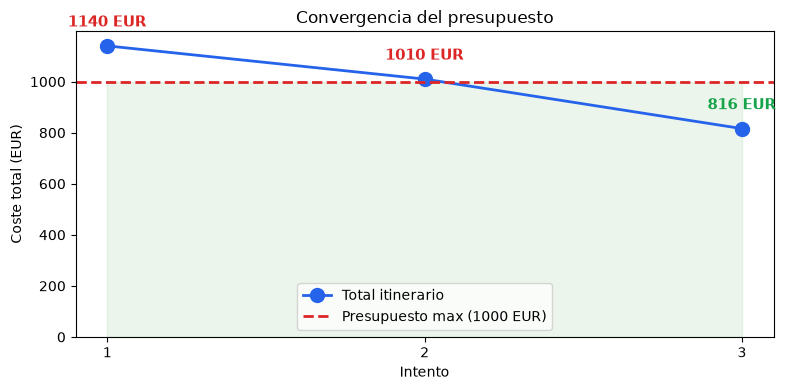

In [5]:
import matplotlib.pyplot as plt

intentos_validos = [i for i, t in flow.state.historial if t is not None]
totales = [t for _, t in flow.state.historial if t is not None]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(intentos_validos, totales, 'o-', color='#2563eb', linewidth=2, markersize=10, label='Total itinerario')
ax.axhline(y=PRESUPUESTO_MAXIMO, color='#dc2626', linestyle='--', linewidth=2, label=f'Presupuesto max ({PRESUPUESTO_MAXIMO} EUR)')
ax.fill_between(intentos_validos, 0, PRESUPUESTO_MAXIMO, alpha=0.08, color='green')

for i, t in zip(intentos_validos, totales):
    color = '#16a34a' if t <= PRESUPUESTO_MAXIMO else '#dc2626'
    ax.annotate(f'{t:.0f} EUR', (i, t), textcoords="offset points", xytext=(0, 14), ha='center', fontsize=11, fontweight='bold', color=color)

ax.set_xlabel('Intento')
ax.set_ylabel('Coste total (EUR)')
ax.set_title('Convergencia del presupuesto')
ax.set_xticks(intentos_validos)
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Qué define este patrón

Dos crews con roles distintos: el planificador genera, el evaluador audita. El evaluador no repite el trabajo del planificador, solo suma, compara y dice qué recortar. El bucle se controla con Python dentro del Flow, y el state (`EvaluatorState`) mantiene el feedback, el historial de costes y el estado de aprobación entre iteraciones.

El gráfico de convergencia muestra cómo el coste baja intento a intento hasta encajar en el presupuesto.